# 07 - ConvLSTM bidireccional final de Situacion 3

Este notebook documenta el entrenamiento real usado para la entrega final. No reentrena el modelo: lee la evidencia final autocontenida en `Entrega_Final/Situacion3`, verifica el checkpoint final y muestra curvas/metrica de test.

Arquitectura de rubrica:

```text
entrada: B x 8 x 273 x H x W
H x W: 48 x 40
ConvLSTM bidireccional
hidden = 128
kernel = 3
2 capas
salida: B x 3 x 3 x H x W
```

In [1]:
from pathlib import Path
import hashlib
import json

import pandas as pd
import matplotlib.pyplot as plt

BASE = Path.cwd()
if BASE.name == 'notebooks':
    S3 = BASE.parent
elif (BASE / 'notebooks').exists() and (BASE / 'outputs').exists():
    S3 = BASE
else:
    S3 = Path('/workspace/geovision-cali-hf/Entrega_Final/Situacion3')

MET = S3 / 'outputs' / 'metricas'
CKPT = S3 / 'checkpoints' / 'convlstm_covariates_spatial_best.pt'

def read_json(path):
    return json.loads(Path(path).read_text(encoding='utf-8'))

def md5_file(path):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b''):
            h.update(chunk)
    return h.hexdigest()

print('S3:', S3)
print('Checkpoint existe:', CKPT.exists())
print('Checkpoint MD5:', md5_file(CKPT) if CKPT.exists() else 'missing')

S3: /workspace/geovision-cali-hf/Entrega_Final/Situacion3
Checkpoint existe: True
Checkpoint MD5: 4be0b8360b37a6d30ed4c386c9c79d0d


## Evidencia Del Entrenamiento

El modelo final corresponde a la version espacial covariada: embeddings GeoVisionCLIP/SAE de 256 dimensiones mas covariables espaciales, espectrales/calendario/SCL, para un total de 273 canales de entrada.

In [2]:
summary = read_json(MET / 'summary_convlstm_bidirectional_spatial.json')
setup = read_json(MET / 'training_setup.json')

print(json.dumps({
    'x_shape': summary['x_shape'],
    'y_shape': summary['y_shape'],
    'split': summary['split'],
    'architecture': summary['architecture'],
    'best_epoch': summary['best_epoch'],
    'best_val_loss': summary['best_val_loss'],
    'test_metrics_all': summary['test_metrics_all'],
    'checkpoint_entrega': str(CKPT.relative_to(S3)),
    'checkpoint_md5': md5_file(CKPT),
}, indent=2, ensure_ascii=False))

{
  "x_shape": [
    119,
    8,
    273,
    48,
    40
  ],
  "y_shape": [
    119,
    3,
    3,
    48,
    40
  ],
  "split": {
    "train": 83,
    "val": 17,
    "test": 19
  },
  "architecture": {
    "bidirectional": true,
    "input_channels": 273,
    "hidden": 128,
    "kernel": 3,
    "layers": 2,
    "output": "B x 3 x 3 x H x W"
  },
  "best_epoch": 9,
  "best_val_loss": 0.14290568977594376,
  "test_metrics_all": {
    "scope": "all",
    "pollutant": "all",
    "horizon_days": "all",
    "rmse": 7.539575304369847,
    "mae": 5.457334518432617,
    "r2": 0.6999095380306244,
    "n": 501
  },
  "checkpoint_entrega": "checkpoints/convlstm_covariates_spatial_best.pt",
  "checkpoint_md5": "4be0b8360b37a6d30ed4c386c9c79d0d"
}


## Curvas De Entrenamiento

La seleccion del checkpoint se hizo por mejor perdida de validacion. El mejor epoch fue `9`, con `val_loss = 0.1429`.

,epoch,train_loss,val_loss,val_rmse,val_mae,val_r2,val_n
0,1,0.600315,0.246577,7.291681,5.180315,0.520646,486
1,2,0.419157,0.214718,6.813546,5.177274,0.581450,486
2,3,0.385764,0.202422,6.610174,4.604934,0.606063,486
3,4,0.330527,0.213765,6.798397,4.434260,0.583309,486
4,5,0.288745,0.181494,6.266578,4.192719,0.645952,486
5,6,0.229900,0.150138,5.710293,3.950148,0.706020,486
6,7,0.215767,0.170102,6.065972,4.187546,0.668257,486
7,8,0.194954,0.154727,5.782423,4.161407,0.698546,486
8,9,0.197321,0.142906,5.560543,3.959960,0.721237,486
9,10,0.193763,0.158643,5.863709,4.109994,0.690012,486


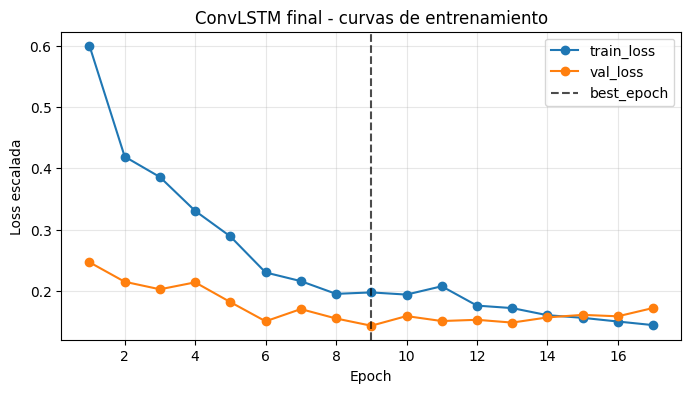

In [3]:
hist = pd.read_csv(MET / 'training_history.csv')
display(hist)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hist['epoch'], hist['train_loss'], marker='o', label='train_loss')
ax.plot(hist['epoch'], hist['val_loss'], marker='o', label='val_loss')
ax.axvline(summary['best_epoch'], color='black', linestyle='--', alpha=0.7, label='best_epoch')
ax.set_title('ConvLSTM final - curvas de entrenamiento')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss escalada')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## Metricas

La metrica agregada final del ConvLSTM espacial covariado es `RMSE=7.54`, `MAE=5.46`, `R2=0.700`. Estas metricas corresponden al modelo profundo antes del ajuste geoestadistico LOO/ST-Kriging.

In [4]:
test_metrics = pd.read_csv(MET / 'test_metrics_masked.csv')
display(test_metrics)

,scope,pollutant,horizon_days,rmse,mae,r2,n
0,all,all,all,7.539575,5.457335,0.699910,501
1,pollutant,NO2,all,9.172060,9.087623,-85.280556,6
2,pollutant,SO2,all,4.950907,3.302065,0.029091,237
3,pollutant,O3,all,9.268908,7.352749,0.216772,258
4,horizon,all,1,7.882140,5.631147,0.725620,167
5,horizon,all,3,7.090847,5.008711,0.699591,166
6,horizon,all,7,7.621065,5.727839,0.667019,168
7,pollutant_horizon,NO2,1,7.697184,7.696972,-1342.729126,2
8,pollutant_horizon,SO2,1,3.795170,2.723177,0.057713,80
9,pollutant_horizon,O3,1,10.349560,8.319451,0.311533,85


## Interpretacion

El entrenamiento final Usa una grilla espacial real `48 x 40`, secuencias de 8 fechas y 273 canales de entrada. El resultado de test muestra capacidad predictiva global razonable (`R2=0.700`) antes de aplicar ST-Kriging.

La rama NO2 tiene muy pocos targets efectivos por la disponibilidad de estaciones; por eso la validacion espacial LOO de NO2 se reporta como no evaluable en la Situacion 3. La evaluacion geoestadistica formal se concentra en SO2 y O3, donde hay soporte espacial suficiente.